# Intro

We decided to find the best neighborhood in Pittsburgh by comparing each neigborhood's average daily traffic, median age of death, and yearly crime.  We decided to use traffic data because it is a good representation of how annoying it is to drive around in an area, so we decided that a low traffic count was good.  We decided to use median age at death because we decided that neighborhoods that allow a person to live longer statistically was better.  We decided to use yearly crime because gauging yearly crime is a viable way of grasping the level of safety a neighborhood contains.

In [1]:
import pandas as pd

traffic_path = 'traffic_final_data.csv'
traffic_data = pd.read_csv(traffic_path)
traffic_data["Rank"] = range(1, len(traffic_data["average_daily_car_traffic"])+1)
traffic_data = traffic_data.rename(columns={"neighborhood":"Neighborhood"})
traffic_data.head(10)

,Neighborhood,average_daily_car_traffic,Rank
0,South Side Flats,115.000000,1
1,Lincoln Place,126.000000,2
2,Lincoln-Lemington-Belmar,195.000000,3
3,Fineview,419.000000,4
4,Allegheny West,477.000000,5
5,New Homestead,666.000000,6
6,Overbrook,777.000000,7
7,Summer Hill,937.000000,8
8,Upper Hill,953.333333,9
9,Central Northside,1189.000000,10


In [2]:
death_data = pd.read_csv('median_age_at_death_submetric.csv')
death_data.head(10)

,Neighborhood,Submetric Score
0,South Shore,1
1,Chateau,2
2,North Shore,3
3,Central Oakland,4
4,East Carnegie,5
5,Allegheny Center,6
6,Swisshelm Park,7
7,New Homestead,8
8,Homewood West,9
9,West End,10


In [3]:
crime_data = pd.read_csv('crime_submetrics.csv')
crime_data.tail(10)


,Neighborhood,Submetric Score
81,Squirrel Hill South,82
82,Mount Washington,83
83,Knoxville,84
84,Bloomfield,85
85,East Liberty,86
86,East Allegheny,87
87,Shadyside,88
88,Carrick,89
89,South Side Flats,90
90,Central Business District,91


# Data cleaning

Before we can combine the datasets, we need to make sure the neighborhood names are consistent.  We can compare the neighborhood columns as sets to see where the differences are, and then clean the data based on what we found.

In [4]:
print(sorted(set(death_data["Neighborhood"]) - set(crime_data["Neighborhood"])))
print(sorted(set(crime_data["Neighborhood"]) - set(death_data["Neighborhood"])))

['Chartiers City', 'Crawford Roberts', 'Mount Oliver Neighborhood', 'South Shore', 'Southside Flats', 'Southside Slopes', 'Spring Hill-Cityview', "Troy Hill/Herr'S Island"]
['Chartiers', 'Crawford-Roberts', 'Lincoln–Lemington–Belmar', 'Mount Oliver', 'South Side Flats', 'South Side Slopes', 'Southshore', 'Spring Hill–City View', 'Troy Hill']


In [5]:
set(traffic_data["Neighborhood"]) - (set(death_data["Neighborhood"]) & set(crime_data["Neighborhood"]))
#St. Clair is Saint Clair in the others

{'Chartiers City',
 'South Side Flats',
 'South Side Slopes',
 'Spring Hill-City View',
 'St. Clair'}

In [7]:
def clean_names(df):
    df["Neighborhood"] = df["Neighborhood"].str.lower()
    df["Neighborhood"] = df["Neighborhood"].str.replace(" ", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("-", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("–", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("city", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("neighborhood", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("/herr'sisland", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("st.", "saint")


    return df

traffic_data = clean_names(traffic_data)
death_data = clean_names(death_data)
crime_data = clean_names(crime_data)


After the data preproccesing, we can see that the names are now consistent across the datasets.

In [8]:
print(sorted(set(death_data["Neighborhood"]) - set(crime_data["Neighborhood"])))
print(sorted(set(crime_data["Neighborhood"]) - set(death_data["Neighborhood"])))

[]
[]


In [9]:
set(traffic_data["Neighborhood"]) - (set(death_data["Neighborhood"]) & set(crime_data["Neighborhood"]))

set()

# Final Rankings

Each of the datasets is ranked based on its own metric, so we can combine the different metrics by adding up the neighborhoods positional rankings (1 meaning they did the best in that metric), and the lower the result the better.  However, traffic data only has 64 out of 90 neighborhoods, so in order to prevent bias towards neiborhoods not scored by traffic data, we set them to 32 (the median ranking of traffic data).

In [10]:
final_df = {}

#Add Traffic data
for index, row in traffic_data.iterrows():
    final_df[row["Neighborhood"]] = row['Rank']

#Add Crime data
for index, row in crime_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['Submetric Score'] + 32   #If a neighborhood is not in traffic data, give it the median traffic ranking
    final_df[row["Neighborhood"]] += row['Submetric Score']

#Add Death data
for index, row in death_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['Submetric Score']
    final_df[row["Neighborhood"]] += row['Submetric Score']


final_df = pd.Series(final_df)
final_df.sort_values().head()

newhomestead     18
summerhill       31
ridgemont        47
swisshelmpark    49
eastcarnegie     49
dtype: int64

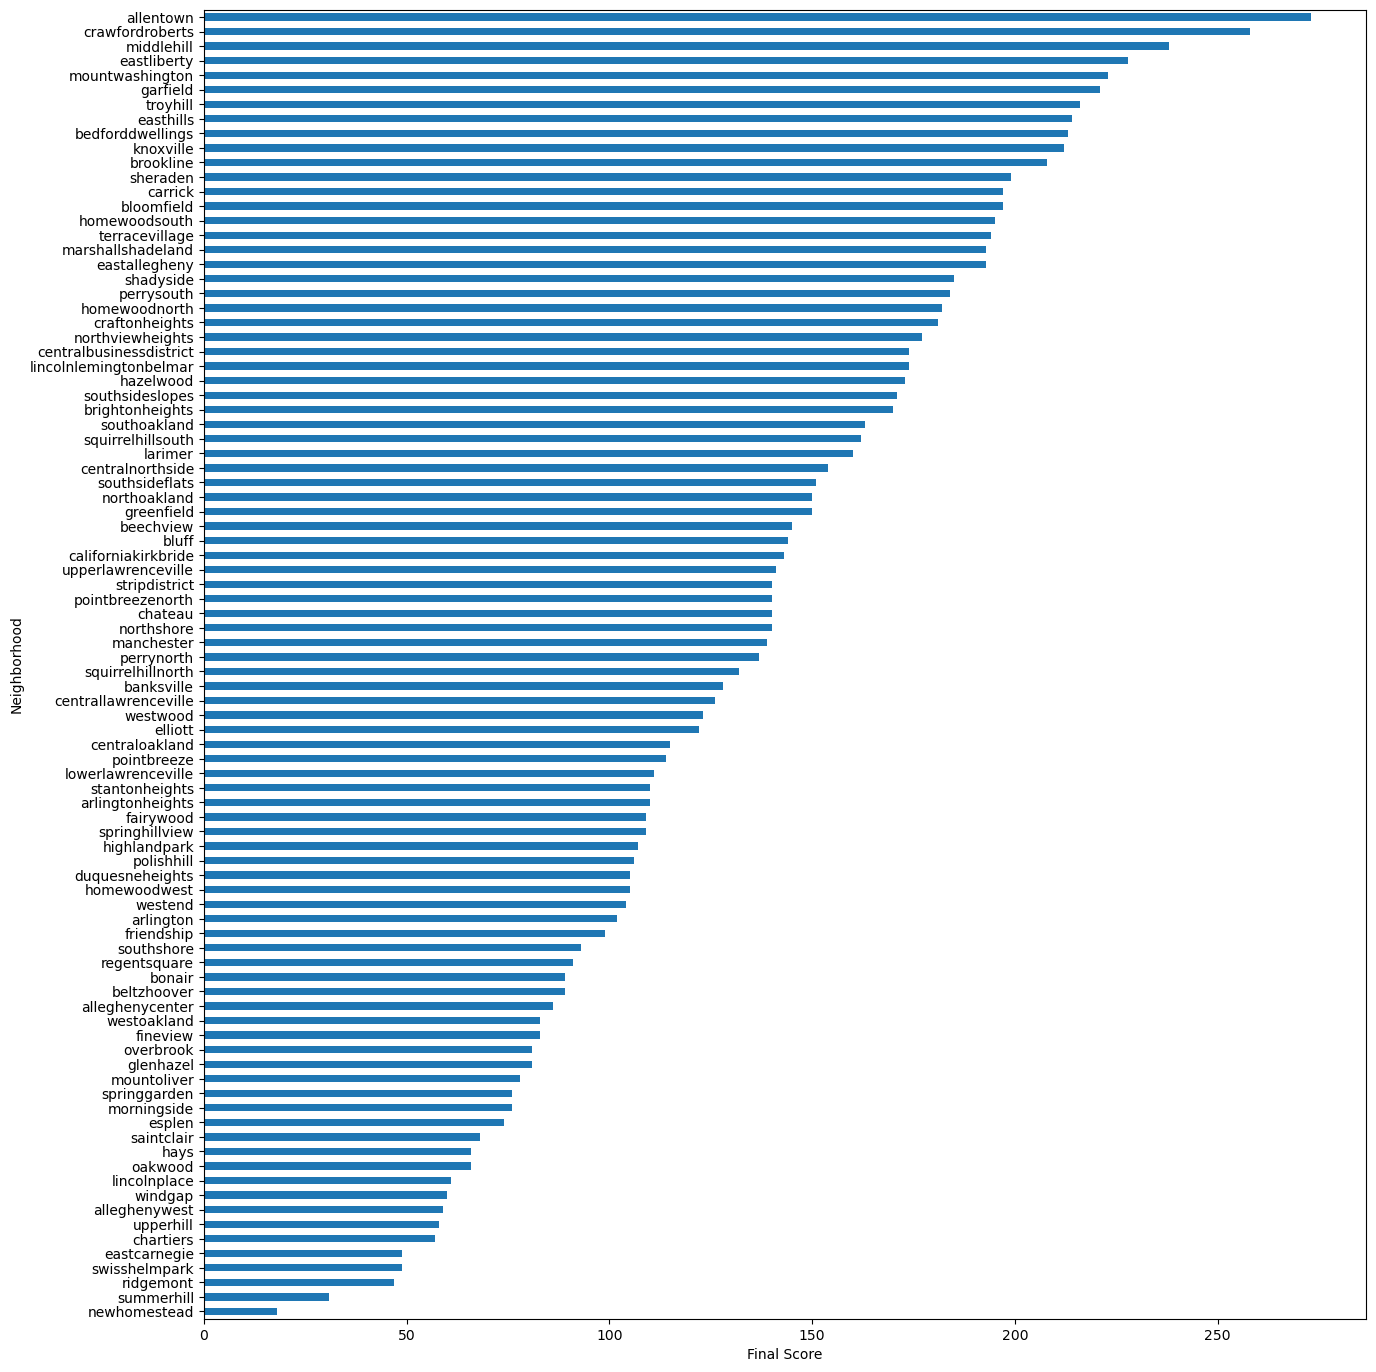

In [11]:
import matplotlib.pyplot as plt

final_df.sort_values(ascending=True).plot(kind='barh', figsize= (15, 17))
plt.xlabel("Final Score")
plt.ylabel("Neighborhood")
plt.show()

# Conclusion

Looking at the final rankings, we each found different conclusions within our submetrics that had our own 'best' neighborhood. Median age at death concluded South Shore by default, traffic data concluded South Side Flats, and criminal data concluded St. Clair. Despite this, a neighborhood that did not necessarily rank at the very top managed to come out on top. New Homestead, represents a well-rounded neighborhood, finishing comfortably within the top 10, and managed to receive the best, or lowest, submetric score. That New Homestead is the best neighborhood according to our metrics. This conclusion aims to balance some of what we believe to be the most valued traits when traditionally considering a neighborhood; in doing so, it managed to sacrifice high individual traits for overall good traits.  

Matt: I kind of have to say that Central Oakland is my favorite neighborhood, because I'm not from around here and I haven't really explored the other neighborhoods yet.  That being said, I still do like Oakland, and it would probably be at least in my top five even if I did know other neighborhoods.  I've never heard of New Homestead before this project, so I was surprised to see it take first place, but looking back at all of our metrics, it was consistently highly ranked, so it does make sense.

Manav: I personally prefer Oakland, particularly Central Oakland, as I have had the most good experiences in this neighborhood. The "best" neighborhood of New Homestead really came out of nowhere for me, as I wasn't considering the other submetrics and only had experience with my top 5 in my submetric of median age at death. Looking at the final data, it is good to see that Central Oakland is within the top 50%.

Steven: Despite the conclusions for my own dataset that Sin Clair would be considered the "best", if I had to select a neighborhood, I would choose Central Oakland. I can admit this decision comes from a shallow view of the city of Pittsburgh, as I haven't ventured elsewhere; however, that's the only neighborhood I can form a grounded opinion on. Through the dense population, walkable streets, and lively personalities, I couldn't imagine choosing anything else.